<a href="https://colab.research.google.com/github/nauliaimtk02/Nur-Aulia-Imtinan/blob/main/ProyekUTS_Anreg_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

In [3]:
# Upload File CSV
uploaded = files.upload()

df = pd.read_csv("Advertising_Data.csv")

# Bersihkan spasi kolom
df.columns = df.columns.str.strip()

# 3. Eksplorasi Data
print("===== HEAD (5 Data Pertama) =====")
print(df.head())

print("\n===== TAIL (5 Data Terakhir) =====")
print(df.tail())

print("\n===== INFO DATA =====")
print(df.info())

print("\n===== DESKRIPTIF STATISTIK =====")
print(df[['TV','Product_Sold']].describe())

# Cek Missing Value
print("\n===== Missing Value per Kolom =====")
print(df.isnull().sum())

print("\n===== Total Missing Value =====")
print(df.isnull().sum().sum())

# 5. Tentukan Variabel X dan Y

# Tentukan variabel
X = df['TV']
Y = df['Product_Sold']

print("\n===== Variabel X (TV) =====")
print(X.head())

print("\n===== Variabel Y (Product_Sold) =====")
print(Y.head())


Saving Advertising_Data.csv to Advertising_Data.csv
===== HEAD (5 Data Pertama) =====
       TV  Billboards  Google_Ads  Social_Media  Influencer_Marketing  \
0  281.42      538.80      123.94        349.30                242.77   
1  702.97      296.53      558.13        180.55                781.06   
2  313.14      295.94      642.96        505.71                438.91   
3  898.52       61.27      548.73        240.93                278.96   
4  766.52      550.72      651.91        666.33                396.33   

   Affiliate_Marketing  Product_Sold  
0               910.10        7164.0  
1               132.43        5055.0  
2               464.23        6154.0  
3               432.27        5480.0  
4               841.93        9669.0  

===== TAIL (5 Data Terakhir) =====
         TV  Billboards  Google_Ads  Social_Media  Influencer_Marketing  \
295  770.05      501.36      694.60        172.26                572.26   
296  512.38      250.83      373.78        366.95      

Uji Asumsi Klasik


===== RINGKASAN MODEL =====
                            OLS Regression Results                            
Dep. Variable:           Product_Sold   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     48.53
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           2.09e-11
Time:                        15:06:53   Log-Likelihood:                -2634.7
No. Observations:                 300   AIC:                             5273.
Df Residuals:                     298   BIC:                             5281.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5886.5533  

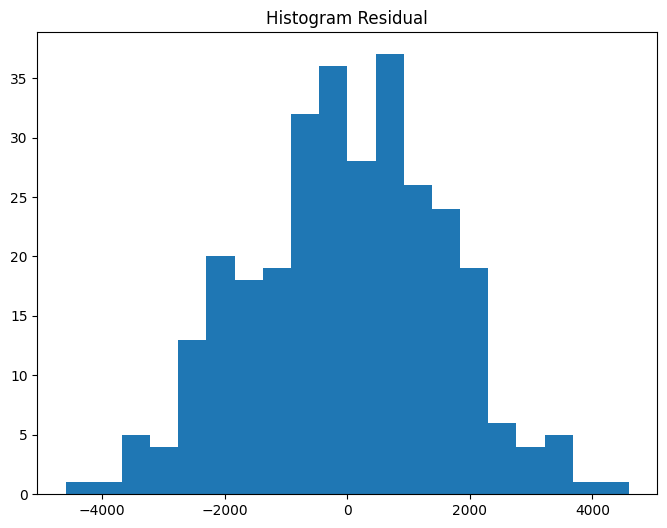

<Figure size 600x600 with 0 Axes>

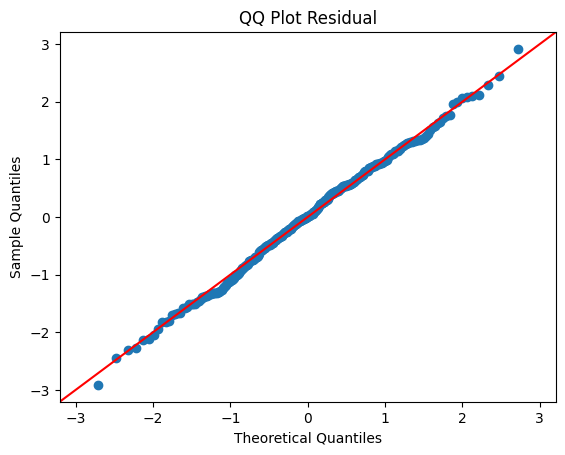

In [4]:
# Model Regresi Linear
X_reg = sm.add_constant(X)
model = sm.OLS(Y, X_reg).fit()
print("\n===== RINGKASAN MODEL =====")
print(model.summary())

# Uji Normalitas Residual
residuals = model.resid
print("===== UJI NORMALITAS (Shapiro-Wilk) =====")
shapiro_test = stats.shapiro(residuals)
print("Statistic :", shapiro_test.statistic)
print("P-value :", shapiro_test.pvalue)

if shapiro_test.pvalue > 0.05:
    print("Kesimpulan : Residual berdistribusi normal")
else:
    print("Kesimpulan : Residual tidak berdistribusi normal")

# Histogram
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=20)
plt.title("Histogram Residual")
plt.show()

# Buat figure baru
plt.figure(figsize=(6,6))

# QQ Plot
sm.qqplot(residuals, line='45', fit=True)

plt.title("QQ Plot Residual")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()


===== UJI BREUSCH-PAGAN =====
Lagrange Multiplier Statistic : 0.06572148813699386
P-value : 0.7976713074779995
Kesimpulan : Tidak terdapat heteroskedastisitas


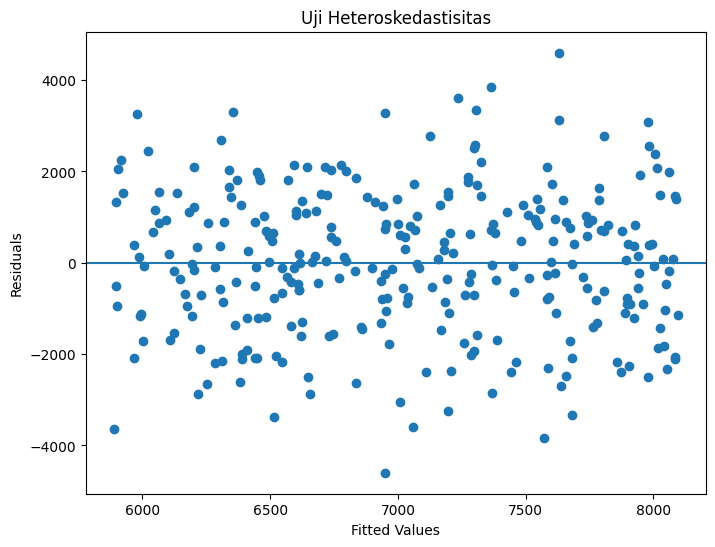

In [5]:
# Uji Heteroskedastisitas (Breusch-Pagan)
bp_test = het_breuschpagan(residuals, X_reg)

print("===== UJI BREUSCH-PAGAN =====")
print("Lagrange Multiplier Statistic :", bp_test[0])
print("P-value :", bp_test[1])

if bp_test[1] > 0.05:
    print("Kesimpulan : Tidak terdapat heteroskedastisitas")
else:
    print("Kesimpulan : Terdapat heteroskedastisitas")

# Scatter Plot Residual vs Fitted
plt.figure(figsize=(8,6))
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Uji Heteroskedastisitas")
plt.show()

In [6]:
# Uji Autokorelasi
dw = durbin_watson(residuals)

print("===== UJI AUTOKORELASI (Durbin-Watson) =====")
print("Nilai DW :", dw)

if 1.5 < dw < 2.5:
    print("Kesimpulan : Tidak terdapat autokorelasi")
else:
    print("Kesimpulan : Terdapat indikasi autokorelasi")

===== UJI AUTOKORELASI (Durbin-Watson) =====
Nilai DW : 1.9131169159935126
Kesimpulan : Tidak terdapat autokorelasi



4️⃣ UJI LINEARITAS (Visual Residual Plot)


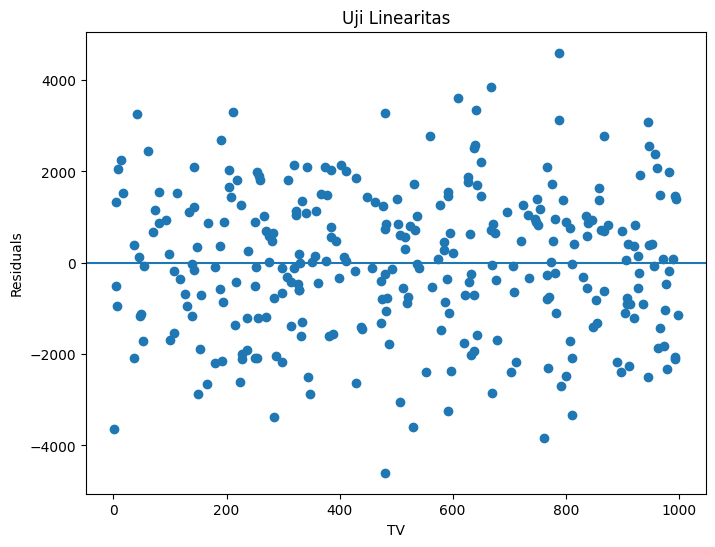

Kesimpulan : Jika titik menyebar acak di sekitar garis 0, maka asumsi linearitas terpenuhi.


In [7]:
# Uji Linearitas
print("\n4️⃣ UJI LINEARITAS (Visual Residual Plot)")
plt.figure(figsize=(8,6))
plt.scatter(X, residuals)
plt.axhline(y=0)
plt.xlabel("TV")
plt.ylabel("Residuals")
plt.title("Uji Linearitas")
plt.show()
print("Kesimpulan : Jika titik menyebar acak di sekitar garis 0, maka asumsi linearitas terpenuhi.")

Cek Missing Value, Outlier & Inskonsistensi Data


In [8]:
# Cek Missing Value

print("\nCEK MISSING VALUE")

missing_per_column = df[['TV','Product_Sold']].isnull().sum()
total_missing = missing_per_column.sum()

print("Missing Value per Kolom:")
print(missing_per_column)
print("Total Missing Value:", total_missing)

if total_missing == 0:
    print("Kesimpulan : Tidak terdapat missing value.")
else:
    print("Kesimpulan : Terdapat missing value, perlu penanganan lebih lanjut.")

# Deteksi Outlier (Metode IQR)
print("\nDETEKSI OUTLIER (Metode IQR)")

def detect_outlier_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return outliers

outlier_tv = detect_outlier_iqr(df, 'TV')
outlier_sales = detect_outlier_iqr(df, 'Product_Sold')

print("Jumlah Outlier TV:", len(outlier_tv))
print("Jumlah Outlier Product_Sold:", len(outlier_sales))

if len(outlier_tv) == 0 and len(outlier_sales) == 0:
    print("Kesimpulan : Tidak terdapat outlier berdasarkan metode IQR.")
else:
    print("Kesimpulan : Terdapat outlier, perlu analisis lebih lanjut.")

# Cek Inkonsistensi Data
print("\nCEK INKONSISTENSI DATA")

# Cek nilai negatif (karena TV & Product_Sold seharusnya tidak negatif)
neg_tv = df[df['TV'] < 0]
neg_sales = df[df['Product_Sold'] < 0]

print("Jumlah nilai negatif pada TV:", len(neg_tv))
print("Jumlah nilai negatif pada Product_Sold:", len(neg_sales))

# Cek duplikasi
duplicate_rows = df.duplicated().sum()
print("Jumlah data duplikat:", duplicate_rows)

if len(neg_tv)==0 and len(neg_sales)==0 and duplicate_rows==0:
    print("Kesimpulan : Tidak terdapat inkonsistensi data.")
else:
    print("Kesimpulan : Terdapat inkonsistensi data, perlu pembersihan.")


CEK MISSING VALUE
Missing Value per Kolom:
TV              0
Product_Sold    0
dtype: int64
Total Missing Value: 0
Kesimpulan : Tidak terdapat missing value.

DETEKSI OUTLIER (Metode IQR)
Jumlah Outlier TV: 0
Jumlah Outlier Product_Sold: 3
Kesimpulan : Terdapat outlier, perlu analisis lebih lanjut.

CEK INKONSISTENSI DATA
Jumlah nilai negatif pada TV: 0
Jumlah nilai negatif pada Product_Sold: 0
Jumlah data duplikat: 0
Kesimpulan : Tidak terdapat inkonsistensi data.


In [9]:
# Model dengan outlier
X1 = sm.add_constant(df["TV"])
Y1 = df["Product_Sold"]

model_full = sm.OLS(Y1, X1).fit()

print("===== MODEL DENGAN OUTLIER =====")
print("R-squared :", model_full.rsquared)
print("Koefisien :")
print(model_full.params)

# Uji normalitas residual
shapiro_full = stats.shapiro(model_full.resid)
print("P-value Shapiro :", shapiro_full.pvalue)

alpha = 0.05

print("===== UJI NORMALITAS RESIDUAL =====\n")

# Model dengan outlier
shapiro_full = stats.shapiro(model_full.resid)
print("Model Dengan Outlier")
print("P-value :", shapiro_full.pvalue)

if shapiro_full.pvalue > alpha:
    print("Kesimpulan : Residual berdistribusi NORMAL\n")
else:
    print("Kesimpulan : Residual TIDAK normal\n")

# Hitung batas IQR
Q1 = df["Product_Sold"].quantile(0.25)
Q3 = df["Product_Sold"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Data tanpa outlier
df_clean = df[(df["Product_Sold"] >= lower) &
              (df["Product_Sold"] <= upper)]

X2 = sm.add_constant(df_clean["TV"])
Y2 = df_clean["Product_Sold"]

model_clean = sm.OLS(Y2, X2).fit()

print("\n===== MODEL TANPA OUTLIER =====")
print("R-squared :", model_clean.rsquared)
print("Koefisien :")
print(model_clean.params)

# Uji normalitas residual
shapiro_clean = stats.shapiro(model_clean.resid)
print("P-value Shapiro :", shapiro_clean.pvalue)

shapiro_clean = stats.shapiro(model_clean.resid)
print("Model Tanpa Outlier")
print("P-value :", shapiro_clean.pvalue)

if shapiro_clean.pvalue > alpha:
    print("Kesimpulan : Residual berdistribusi NORMAL\n")
else:
    print("Kesimpulan : Residual TIDAK normal\n")

===== MODEL DENGAN OUTLIER =====
R-squared : 0.14004628698814459
Koefisien :
const    5886.553274
TV          2.212798
dtype: float64
P-value Shapiro : 0.797123666927368
===== UJI NORMALITAS RESIDUAL =====

Model Dengan Outlier
P-value : 0.797123666927368
Kesimpulan : Residual berdistribusi NORMAL


===== MODEL TANPA OUTLIER =====
R-squared : 0.1328412048647949
Koefisien :
const    5968.399524
TV          2.078480
dtype: float64
P-value Shapiro : 0.22964708734081174
Model Tanpa Outlier
P-value : 0.22964708734081174
Kesimpulan : Residual berdistribusi NORMAL



Identifikasi Hubungan Variabel

Koefisien Korelasi (r) : 0.3742275871553891
P-value : 2.087568086058889e-11


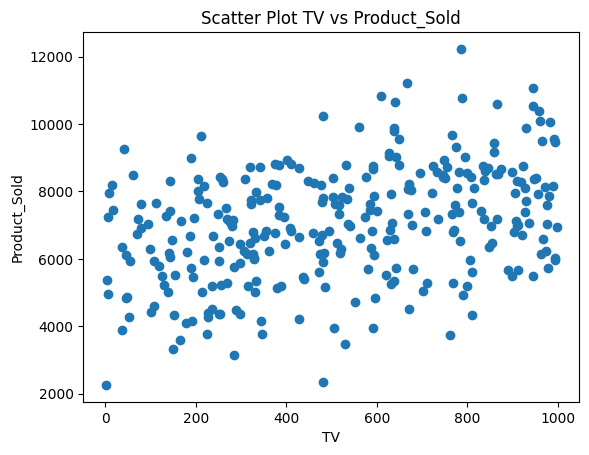

t hitung : 6.966367696806223


In [10]:
# Korelasi Pearson
r, p_value = stats.pearsonr(X, Y)
n = len(X)

print("Koefisien Korelasi (r) :", r)
print("P-value :", p_value)

# Visualisasi Scatter Plot
plt.scatter(X, Y)
plt.xlabel("TV")
plt.ylabel("Product_Sold")
plt.title("Scatter Plot TV vs Product_Sold")
plt.show()

# Uji t korelasi
t_stat = r * np.sqrt(n-2) / np.sqrt(1 - r**2)
print("t hitung :", t_stat)